In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np
import pandas as pd


In [3]:
df=pd.read_csv('cleaned_insurance.csv')

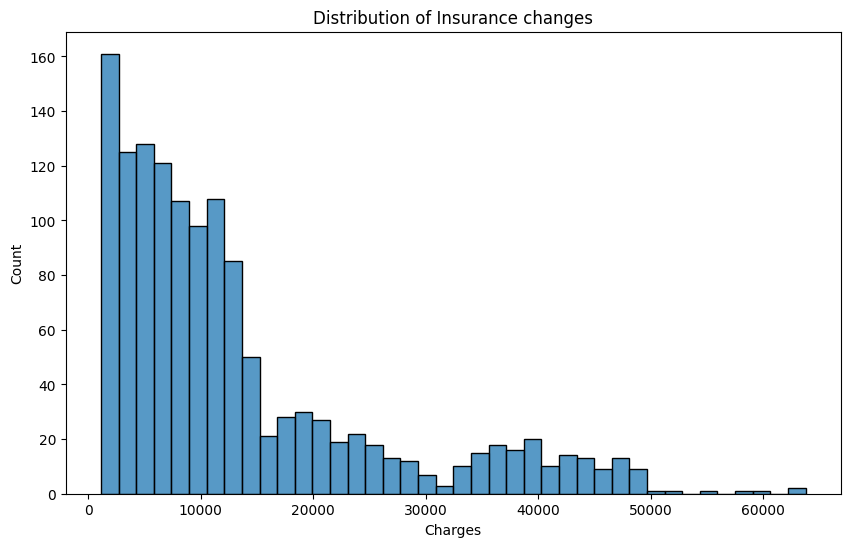

In [4]:
plt.figure(figsize=(10,6))
sns.histplot(df['charges'],kde=False, bins=40)
plt.title('Distribution of Insurance changes')
plt.xlabel('Charges')
plt.ylabel('Count')

plt.show()


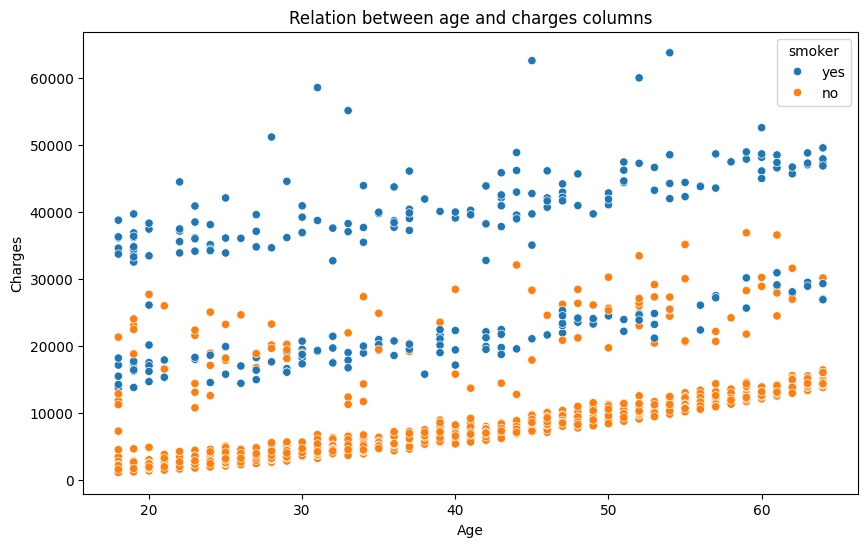

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['age'],y=df['charges'], hue=df['smoker'])
plt.title('Relation between age and charges columns')

plt.xlabel('Age')
plt.ylabel('Charges')

plt.show()

# Scatter plot of BMI vs Charges (hue = smoker)


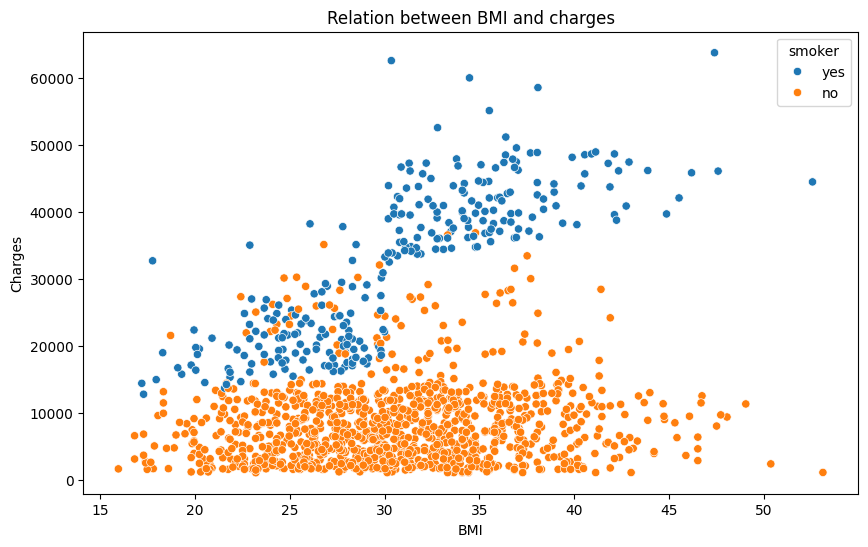

In [6]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['bmi'], y=df['charges'], hue=df['smoker'])
plt.title('Relation between BMI and charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

# Smoker vs Charges boxplot


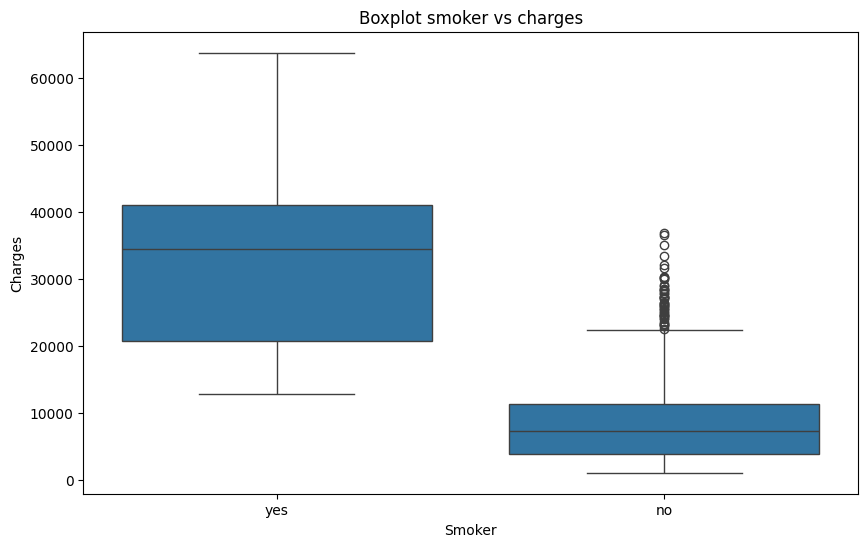

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['smoker'],y=df['charges'],data=df)
plt.title('Boxplot smoker vs charges')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

# Region vs Charges boxplot

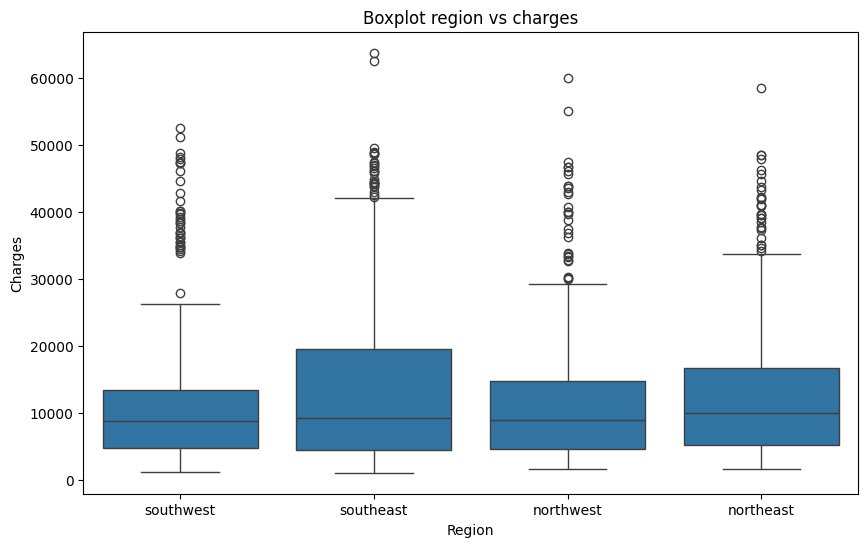

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['region'],y=df['charges'],data=df)
plt.title('Boxplot region vs charges')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

# Children vs Charges

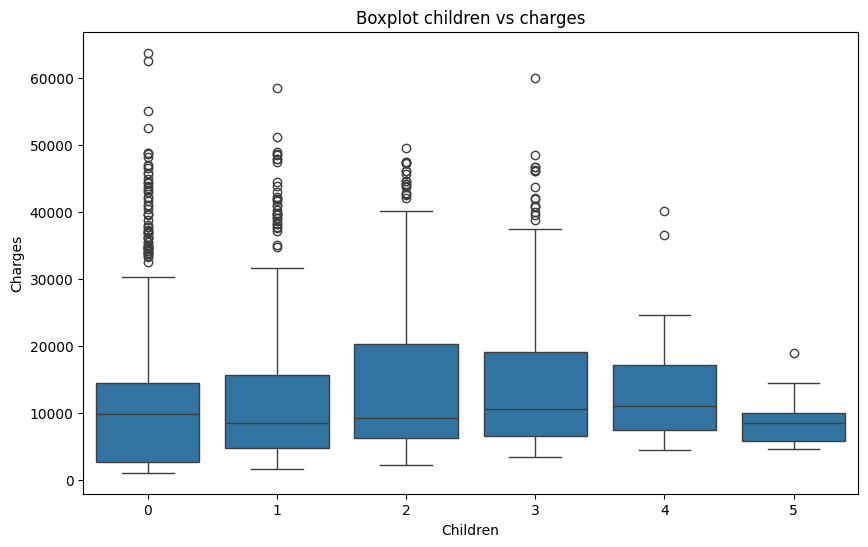

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['children'],y=df['charges'],data=df)
plt.title('Boxplot children vs charges')
plt.xlabel('Children')
plt.ylabel('Charges')
plt.show()

# Sex vs charges

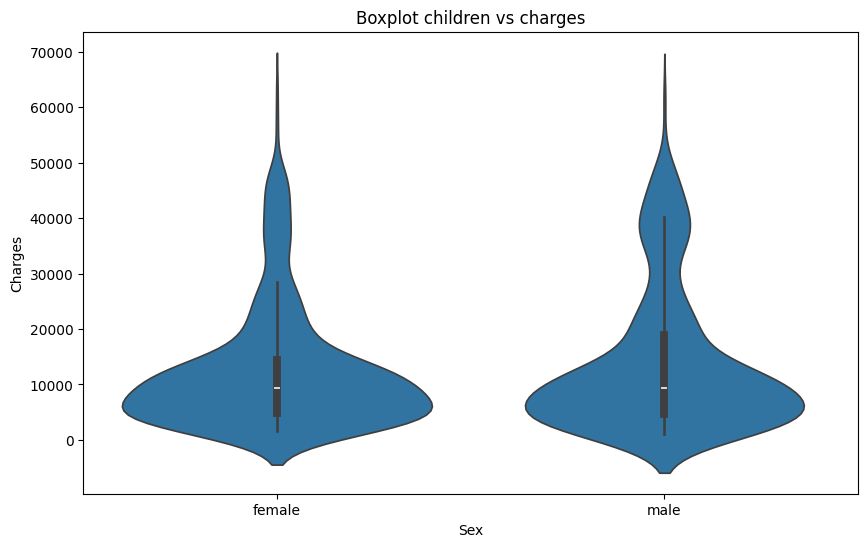

In [10]:
plt.figure(figsize=(10,6))
sns.violinplot(x=df['sex'],y=df['charges'],data=df)
plt.title('Boxplot children vs charges')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()

In [11]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


In [12]:
gender_dict={'female':0,'male':1}
smoke_dict={'no':0,'yes':1}

df['smoker_enc']=df['smoker'].map(smoke_dict)
df['sex_enc']=df['sex'].map(gender_dict)

In [13]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_enc,sex_enc
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,0,1
1333,18,female,31.920,0,no,northeast,2205.98080,0,0
1334,18,female,36.850,0,no,southeast,1629.83350,0,0
1335,21,female,25.800,0,no,southwest,2007.94500,0,0


In [17]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_enc,sex_enc
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,0,1
1333,18,female,31.920,0,no,northeast,2205.98080,0,0
1334,18,female,36.850,0,no,southeast,1629.83350,0,0
1335,21,female,25.800,0,no,southwest,2007.94500,0,0


In [18]:
df_new=df.drop(columns=['sex','region','smoker'])

In [19]:
df_new.corr()

,age,bmi,children,charges,smoker_enc,sex_enc
age,1.000000,0.109344,0.041536,0.298308,-0.025587,-0.019814
bmi,0.109344,1.000000,0.012755,0.198401,0.003746,0.046397
children,0.041536,0.012755,1.000000,0.067389,0.007331,0.017848
charges,0.298308,0.198401,0.067389,1.000000,0.787234,0.058044
smoker_enc,-0.025587,0.003746,0.007331,0.787234,1.000000,0.076596
sex_enc,-0.019814,0.046397,0.017848,0.058044,0.076596,1.000000


<Axes: >

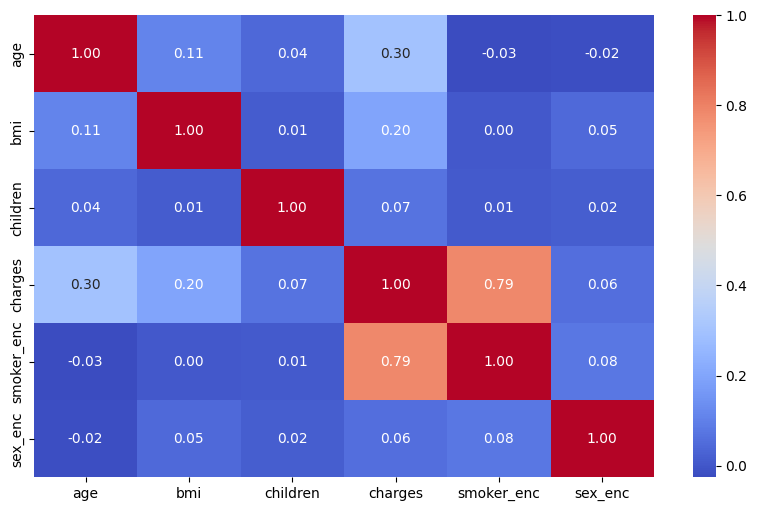

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(df_new.corr(), annot=True,cmap='coolwarm', fmt='.2f')

# BMI Group × Smoker Grouped Bar Chart

In [21]:
def weight_measure(weight) :
  if weight < 25:
    return 'Normal'
  elif 25 < weight <= 30:
    return 'Overweight'
  else:
    return 'Obese'


In [22]:
df['bmi_group']=df['bmi'].apply(lambda x: weight_measure(x))

In [23]:
df[['bmi_group','bmi']]

,bmi_group,bmi
0,Overweight,27.900
1,Obese,33.770
2,Obese,33.000
3,Normal,22.705
4,Overweight,28.880
...,...,...
1332,Obese,30.970
1333,Obese,31.920
1334,Obese,36.850
1335,Overweight,25.800


In [24]:
df.groupby(['bmi_group','smoker_enc'])['charges'].mean()

bmi_group   smoker_enc
Normal      0              7515.708891
            1             19839.278309
Obese       0              8872.106119
            1             41692.808992
Overweight  0              8226.088675
            1             22491.182935
Name: charges, dtype: float64

In [25]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_enc,sex_enc,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,0,1,Obese
2,28,male,33.000,3,no,southeast,4449.46200,0,1,Obese
3,33,male,22.705,0,no,northwest,21984.47061,0,1,Normal
4,32,male,28.880,0,no,northwest,3866.85520,0,1,Overweight
...,...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,0,1,Obese
1333,18,female,31.920,0,no,northeast,2205.98080,0,0,Obese
1334,18,female,36.850,0,no,southeast,1629.83350,0,0,Obese
1335,21,female,25.800,0,no,southwest,2007.94500,0,0,Overweight


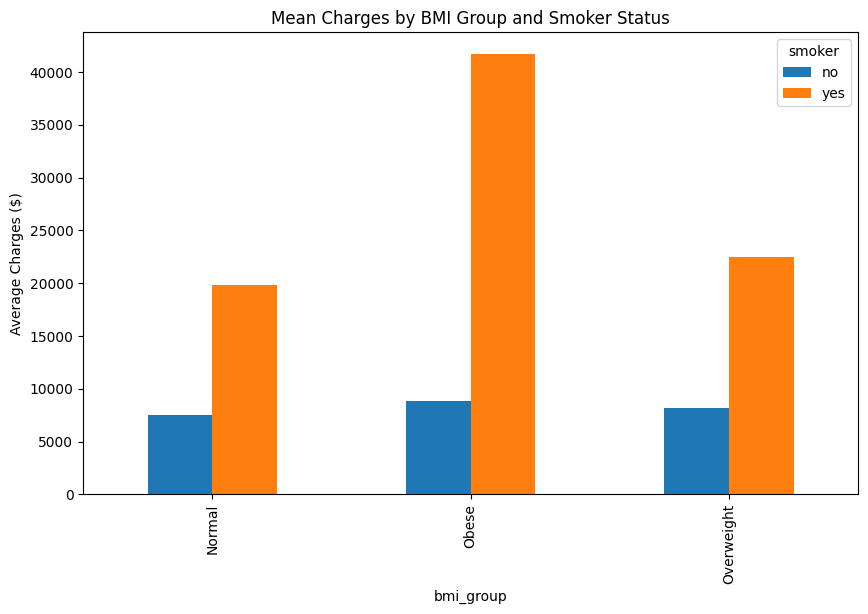

In [26]:
df.groupby(['bmi_group', 'smoker'])['charges'].mean().unstack().plot(kind='bar', figsize=(10,6))
plt.title('Mean Charges by BMI Group and Smoker Status')
plt.ylabel('Average Charges ($)')
plt.show()

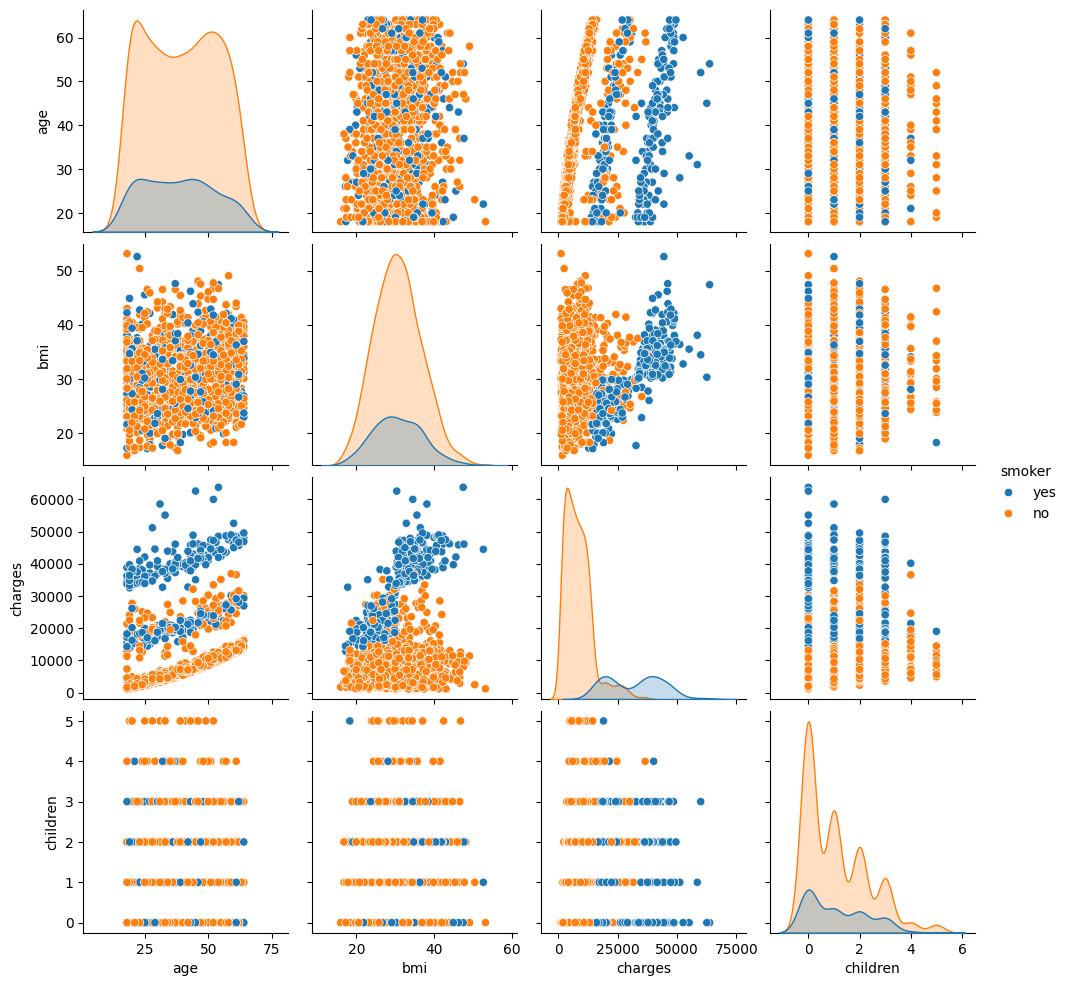

In [27]:
sns.pairplot(df[['age', 'bmi', 'charges', 'children', 'smoker']], hue='smoker')
plt.show()